In [1]:
from pathlib import Path
import sys
from config import CITY_NAME

# Evita extensões opcionais que podem causar conflito em alguns ambientes.
sys.modules['numexpr'] = None
sys.modules['bottleneck'] = None

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DATA_DIR = Path('./dados')
EDGES = DATA_DIR / 'edges_antenna.parquet'
ANTENNAS = DATA_DIR / 'antennas.parquet'

In [2]:
parquet_file1 = pq.ParquetFile(EDGES)
edges = parquet_file1.read().to_pandas()
parquet_file2 = pq.ParquetFile(ANTENNAS)
antenas = parquet_file2.read().to_pandas()


In [3]:
antenas.info()


<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   antenna_id                 7 non-null      int64
 1   residence_geometry         7 non-null      str  
 2   residence_city             7 non-null      str  
 3   residence_quintile_state   7 non-null      str  
 4   residence_quintile_nation  7 non-null      str  
dtypes: int64(1), str(4)
memory usage: 954.0 bytes


In [4]:
edges.info()


<class 'pandas.DataFrame'>
Index: 12432 entries, 0 to 12431
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_emisor              12432 non-null  str    
 1   id_receiver            12432 non-null  str    
 2   q_calls                12432 non-null  int64  
 3   residence_distance_km  12432 non-null  float64
 4   calls_duration_total   12432 non-null  float64
 5   avg_duration_per_call  12432 non-null  float64
 6   emissor_antenna_id     12432 non-null  Int64  
 7   receptor_antenna_id    12432 non-null  Int64  
dtypes: Int64(2), float64(3), int64(1), str(2)
memory usage: 1.6 MB


# Dicionário da tabela `edges`

| Coluna | Como será usada aqui |
|----------|----------|
| `id_emisor` | Identificador anonimizado do usuário que realizou a chamada. Representa o nó de origem da aresta. |
| `id_receiver` | Identificador anonimizado do usuário que recebeu a chamada. Representa o nó de destino da aresta. |
| `q_calls` | Quantidade total de chamadas realizadas entre o emissor e o receptor. Utilizada como medida de intensidade da conexão. |
| `calls_duration_total` | Soma da duração de todas as chamadas entre o emissor e o receptor. Utilizada como peso alternativo da aresta. |
| `avg_duration_per_call` | Duração média das chamadas entre o emissor e o receptor. Utilizada para caracterizar o perfil da interação. |
| `residence_distance_km` | Distância residencial, em quilômetros, entre emissor e receptor. Utilizada para análises espaciais da rede. |
| `emissor_antenna_id` | Identificador da antena residencial associada ao emissor. Utilizado para relacionar usuários à infraestrutura espacial da rede. |
| `receptor_antenna_id` | Identificador da antena residencial associada ao receptor. Utilizado para relacionar usuários à infraestrutura espacial da rede. |

## Interpretação da tabela

Cada linha representa uma **aresta da rede de comunicação**, contendo:

- quem realizou a ligação;
- quem recebeu a ligação;
- a intensidade da interação (`q_calls`);
- a duração acumulada da comunicação (`calls_duration_total`);
- a duração média das chamadas (`avg_duration_per_call`);
- a distância geográfica entre os usuários (`residence_distance_km`);
- as antenas residenciais associadas aos dois extremos da aresta.

Essa estrutura permite construir grafos ponderados e realizar análises de:

- distribuição de grau;
- centralidade;
- comunidades;
- small-world;
- dependência espacial das comunicações;
- fluxo de chamadas entre regiões da cidade.

---

# Dicionário da tabela `antenas`

| Coluna | Como será usada aqui |
|----------|----------|
| `antenna_id` | Identificador único da antena residencial. Utilizado como chave de ligação entre usuários e informações geográficas. |
| `residence_geometry` | Identificador geográfico da região residencial associada à antena. |
| `residence_city` | Cidade associada à antena residencial. Utilizada para análises espaciais e caracterização territorial. |
| `residence_quintile_state` | Quintil socioeconômico estadual da região atendida pela antena. Utilizado para análises de desigualdade e homofilia socioeconômica. |
| `residence_quintile_nation` | Quintil socioeconômico nacional da região atendida pela antena. Utilizado para análises complementares de estratificação social. |

## Interpretação da tabela

Cada linha representa uma **antena residencial distinta** identificada na base de dados.

A tabela contém atributos geográficos e socioeconômicos associados a cada antena, permitindo:

- localizar espacialmente os usuários da rede;
- caracterizar regiões da cidade;
- investigar padrões de comunicação entre diferentes estratos socioeconômicos;
- agregar métricas da rede por antena;
- construir redes agregadas entre antenas.

Essa separação reduz a redundância dos dados, uma vez que informações geográficas e socioeconômicas deixam de ser repetidas em todas as arestas e passam a ser armazenadas uma única vez para cada antena.


# Construção da Rede


In [5]:
import networkx as nx


## Grafo básico


In [6]:
# A base tem chamadas dirigidas. Para analisar comunidades sociais em um grafo
# não-direcionado, primeiro agregamos A->B e B->A no mesmo par de usuários.
edge_pairs = edges.copy()

edge_pairs["source"] = np.minimum(
    edge_pairs["id_emisor"].astype(str),
    edge_pairs["id_receiver"].astype(str)
)
edge_pairs["target"] = np.maximum(
    edge_pairs["id_emisor"].astype(str),
    edge_pairs["id_receiver"].astype(str)
)

edges_graph = (
    edge_pairs
    .groupby(["source", "target"], as_index=False)
    .agg(
        q_calls=("q_calls", "sum"),
        calls_duration_total=("calls_duration_total", "sum"),
        avg_duration_per_call=("avg_duration_per_call", "mean"),
        residence_distance_km=("residence_distance_km", "mean"),
    )
)

edges_graph["weight"] = (
    np.log1p(edges_graph["q_calls"]) *
    np.log1p(edges_graph["calls_duration_total"])
)

user_antennas = pd.concat([
    edges[["id_emisor", "emissor_antenna_id"]]
    .rename(columns={"id_emisor": "user_id", "emissor_antenna_id": "antenna_id"}),
    edges[["id_receiver", "receptor_antenna_id"]]
    .rename(columns={"id_receiver": "user_id", "receptor_antenna_id": "antenna_id"}),
])

user_antenna = (
    user_antennas
    .dropna()
    .groupby("user_id")["antenna_id"]
    .agg(lambda s: s.mode().iat[0])
)

G = nx.from_pandas_edgelist(
    edges_graph,
    source="source",
    target="target",
    edge_attr=[
        "weight",
        "q_calls",
        "calls_duration_total",
        "avg_duration_per_call",
        "residence_distance_km",
    ]
)

print(f"Linhas originais dirigidas: {len(edges):,}")
print(f"Arestas não-direcionadas agregadas: {len(edges_graph):,}")
print(f"Nós: {G.number_of_nodes():,}")
print(f"Arestas: {G.number_of_edges():,}")


Linhas originais dirigidas: 12,432
Arestas não-direcionadas agregadas: 8,341
Nós: 3,112
Arestas: 8,341


In [7]:
print(nx.density(G))


0.0017230922037153181


Uma densidade muito baixa indica que:

a rede é esparsa;

as pessoas mantêm poucos contatos em relação ao total da população;

provavelmente existem comunidades locais;

faz sentido procurar hubs e estruturas sociais.


## Distribuição de grau


### Histograma de graus


In [8]:
graus = [d for _, d in G.degree()]


Text(0, 0.5, 'Frequência')

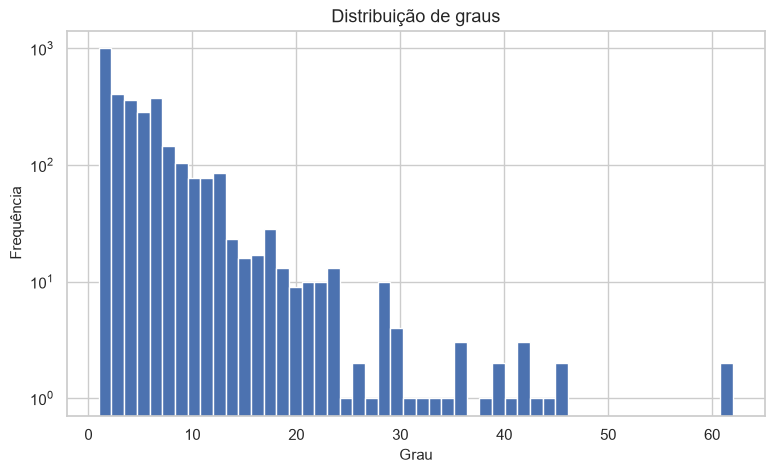

In [9]:
plt.hist(graus, bins=50, log=True);
plt.title("Distribuição de graus")
plt.xlabel("Grau")
plt.ylabel("Frequência")


In [10]:
pd.Series(graus).describe()


count    3112.000000
mean        5.360540
std         5.343594
min         1.000000
25%         2.000000
50%         4.000000
75%         7.000000
max        62.000000
dtype: float64

A distribuição de grau da rede revela uma forte concentração de usuários com poucas conexões. Observa-se que 25% dos nós possuem apenas uma conexão, enquanto a mediana é igual a 2, indicando que metade dos usuários se comunica com no máximo duas pessoas distintas. Além disso, 75% dos nós apresentam grau inferior ou igual a 3.

Apesar dessa concentração em baixos valores de grau, existem usuários significativamente mais conectados, alcançando grau máximo de 56. A diferença entre a mediana (2) e o grau máximo (56) sugere a presença de uma cauda longa na distribuição, característica frequentemente observada em redes sociais e de comunicação.

Esse comportamento indica uma rede heterogênea, composta majoritariamente por usuários com poucas conexões e por um pequeno conjunto de nós altamente conectados, que podem atuar como hubs na estrutura da rede.


## CCDF


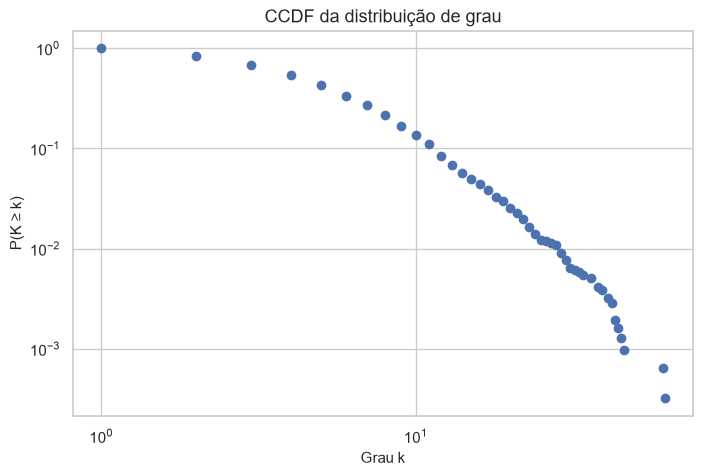

In [11]:
graus = np.array(graus)

x = np.sort(np.unique(graus))
ccdf = [np.mean(graus >= k) for k in x]

plt.figure(figsize=(8,5))
plt.loglog(x, ccdf, marker='o', linestyle='')

plt.xlabel("Grau k")
plt.ylabel("P(K ≥ k)")
plt.title("CCDF da distribuição de grau")
plt.grid(True)
plt.show()


A função de distribuição acumulada complementar (CCDF, *Complementary Cumulative Distribution Function*) representa a probabilidade de um nó possuir grau maior ou igual a um determinado valor (k). Em outras palavras, para cada valor de grau, a CCDF informa qual fração da rede possui pelo menos aquela quantidade de conexões.

De forma intuitiva, a CCDF pode ser interpretada como a parcela dos usuários que permanece "acima" de um determinado grau. Por exemplo, se para (k=10) a CCDF vale 0,01, isso significa que aproximadamente 1% dos usuários possuem 10 ou mais conexões. Assim, enquanto um histograma mostra quantos nós existem em cada grau, a CCDF mostra a proporção acumulada de nós que possuem grau igual ou superior a cada valor considerado.

A principal vantagem da CCDF é evidenciar o comportamento da cauda da distribuição, permitindo identificar a presença de nós altamente conectados (hubs) que podem ficar ocultos em histogramas convencionais.

Observa-se que a probabilidade decresce gradualmente à medida que o grau aumenta, indicando que a maior parte dos usuários possui poucas conexões, enquanto uma pequena parcela apresenta número significativamente maior de contatos. Esse comportamento evidencia a existência de uma cauda longa na distribuição de grau.

Além disso, a curva apresenta um trecho aproximadamente linear em escala log-log, característica frequentemente associada a distribuições de cauda pesada encontradas em redes sociais e de comunicação. Esses resultados sugerem que a rede é estruturalmente heterogênea, composta por muitos usuários pouco conectados e por um conjunto reduzido de nós que atuam como hubs na rede.


## Componentes conexas


In [12]:
components = list(nx.connected_components(G))

sizes = sorted(
    [len(c) for c in components],
    reverse=True
)

print(sizes)


[3021, 4, 4, 4, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [13]:
largest_cc = max(
    nx.connected_components(G),
    key=len
)

G_main = G.subgraph(largest_cc).copy()


In [14]:
print(G_main)


Graph with 3021 nodes and 8289 edges


Uma componente conexa corresponde a um conjunto de nós em que existe pelo menos um caminho ligando qualquer par de usuários pertencentes ao mesmo grupo. Em outras palavras, todos os indivíduos de uma mesma componente podem ser alcançados por meio de conexões diretas ou indiretas.

A rede analisada apresentou 2549 componentes conexas distintas, indicando a existência de diversos grupos independentes de usuários. Entretanto, observou-se a presença de uma componente gigante contendo 18043 nós, o que representa aproximadamente 72% de todos os usuários da rede.

Esse resultado sugere que a maior parte dos indivíduos pertence a uma única estrutura conectada, permitindo que informações, influências ou interações se propaguem através de caminhos indiretos entre a maioria dos usuários. As demais componentes são significativamente menores e representam grupos isolados ou fracamente conectados ao restante da rede.

A coexistência de uma componente gigante com diversas componentes pequenas é um comportamento frequentemente observado em redes reais de comunicação e interação social, indicando uma estrutura globalmente conectada, mas com a presença de grupos periféricos que permanecem desconectados da maior parte da população.


## Clustering


In [15]:
nx.average_clustering(G)


0.12628136034070184

O coeficiente de clustering mede a tendência de formação de grupos locais na rede. De forma intuitiva, essa métrica avalia a probabilidade de que dois vizinhos de um mesmo usuário também estejam conectados entre si, formando estruturas triangulares.

A rede apresentou coeficiente de clustering médio igual a 0,16. Isso indica que aproximadamente 16% das conexões potenciais entre vizinhos efetivamente ocorrem na rede.

Embora esse valor esteja distante do máximo possível (1,0), ele é significativamente superior ao esperado para redes puramente aleatórias, sugerindo a presença de agrupamentos locais de usuários. Esse comportamento é compatível com redes reais de comunicação, nas quais indivíduos pertencentes a círculos sociais semelhantes — como familiares, amigos, colegas de trabalho ou vizinhos — tendem a estabelecer conexões entre si.

A presença de clustering não nulo reforça a hipótese de que a rede apresenta organização social subjacente, com formação de grupos locais e padrões de interação que não podem ser explicados apenas pelo acaso.


## Centralidades e hubs

A distribuição de grau mostrou que poucos usuários concentram muitas conexões. Para caracterizar
melhor esses usuários centrais, calculamos algumas medidas de centralidade sobre a componente gigante:

- **grau**: número de contatos diretos;
- **força**: grau ponderado pelo número de chamadas (`q_calls`);
- **intermediação (betweenness)**: com que frequência o nó aparece nos caminhos mais curtos entre
  outros pares; valores altos indicam pontes que conectam regiões diferentes da rede;
- **autovetor (eigenvector)**: importância do nó por estar ligado a outros nós importantes.

O betweenness exato seria custoso em ~18 mil nós, por isso usamos a aproximação por amostragem de
`k=500` nós-fonte, suficiente para ranquear os principais hubs.

In [16]:
# Centralidades sobre a componente gigante (G_main)
deg = dict(G_main.degree())
strength = dict(G_main.degree(weight="q_calls"))            # grau ponderado por chamadas
betw = nx.betweenness_centrality(G_main, k=500, weight=None, seed=42)
eig = nx.eigenvector_centrality(G_main, max_iter=1000, weight="weight")

centralidades = pd.DataFrame({"user_id": list(G_main.nodes())})
centralidades["grau"] = centralidades["user_id"].map(deg)
centralidades["forca_chamadas"] = centralidades["user_id"].map(strength)
centralidades["intermediacao"] = centralidades["user_id"].map(betw)
centralidades["autovetor"] = centralidades["user_id"].map(eig)

top_hubs = centralidades.sort_values("grau", ascending=False).head(15)
top_hubs

,user_id,grau,forca_chamadas,intermediacao,autovetor
149,E5C850BFDA1EA9685BCD5B16281809B6,62,135,0.081340,0.000006
395,B88B54926FCE450CE272C26866E098C9,61,574,0.055535,0.000015
699,222A55BE7B42CF3CA755300245581F55,46,669,0.003862,0.280912
44,00CE842248B10B46DCF2C8195F5949B5,45,313,0.008194,0.177182
70,7FA8772A381F0573D273A5ABAEEA18EA,44,489,0.001902,0.260474
81,E12DD48E40695BEF1BD387BF60A0309E,43,561,0.001277,0.266040
69,7AB28929A558AF130C457A05DBF5A0D2,42,328,0.002118,0.166405
79,DD4B7681C2666E7901A82B4615384CEC,42,492,0.002240,0.256718
66,664275279AF3C4C9BA07A9226706BBD2,42,503,0.001170,0.233162
64,601CFEB4ECA5469ED54376AF1D695875,41,375,0.002661,0.208716


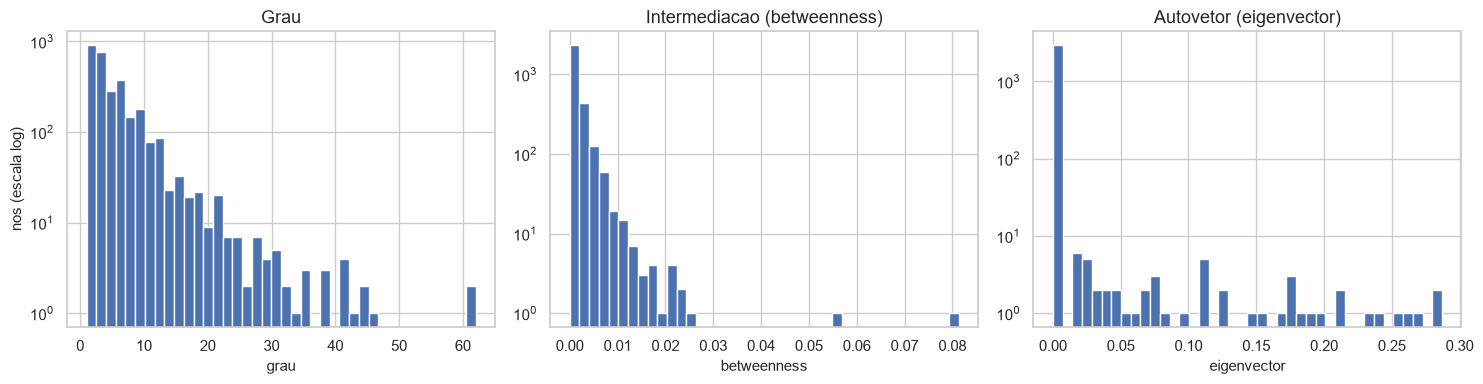

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(centralidades["grau"], bins=40, log=True)
axes[0].set_title("Grau")
axes[0].set_xlabel("grau")
axes[0].set_ylabel("nos (escala log)")

axes[1].hist(centralidades["intermediacao"], bins=40, log=True)
axes[1].set_title("Intermediacao (betweenness)")
axes[1].set_xlabel("betweenness")

axes[2].hist(centralidades["autovetor"], bins=40, log=True)
axes[2].set_title("Autovetor (eigenvector)")
axes[2].set_xlabel("eigenvector")

plt.tight_layout()
plt.show()

As três medidas são fortemente concentradas: a grande maioria dos usuários tem centralidade
baixa e um pequeno conjunto se destaca como hub. Os nós com alta intermediação são especialmente
relevantes porque funcionam como pontes entre grupos; sua remoção tenderia a fragmentar a rede.
Mais adiante, na seção geográfica, localizamos espacialmente esses hubs sobre o mapa de Campinas.

## Comunidades


In [18]:
from networkx.algorithms.community import louvain_communities

communities = louvain_communities(
    G_main,
    weight="weight",
    seed=42
)


In [19]:
community_rows = []

for community_id, community in enumerate(communities):

    for user_id in community:

        community_rows.append(
            {
                "user_id": user_id,
                "community": community_id
            }
        )

community_df = pd.DataFrame(community_rows)

community_sizes = (
    community_df
    .groupby("community")
    .size()
    .rename("community_size")
    .reset_index()
)

community_sizes["community_rank"] = (
    community_sizes["community_size"]
    .rank(method="first", ascending=False)
    .astype(int)
)

community_df = community_df.merge(
    community_sizes,
    on="community",
    how="left"
)


In [20]:
community_df


,user_id,community,community_size,community_rank
0,39C5C03536E18A050771B6D64EDA516F,0,79,10
1,906AEBA10449BB72407AA70D32632AC1,0,79,10
2,B500849FA83AB9FCCDC88D1890531096,0,79,10
3,5FAEDD5186C7EB85B88A120D952E197D,0,79,10
4,A57023228540C405F96AAB337A83006B,0,79,10
...,...,...,...,...
3016,A23B55E0005C0BB7BEE6FC96944140C1,71,57,21
3017,9A4E0307A66AE731C32E7BABE2D81EBD,71,57,21
3018,988F40A023E7BD81158767A7420C7428,71,57,21
3019,EF8EAD36489652582F132178057E9930,71,57,21


In [21]:
sizes = sorted(
    [len(c) for c in communities],
    reverse=True
)

sizes[:20]


[109,
 91,
 88,
 88,
 88,
 85,
 84,
 81,
 80,
 79,
 79,
 78,
 75,
 72,
 72,
 68,
 68,
 62,
 59,
 58]

In [22]:
from networkx.algorithms.community import modularity

Q = modularity(G_main, communities, weight="weight")
print(Q)


0.8422093509534698


In [23]:
print(f"Componentes conectadas no grafo completo: {nx.number_connected_components(G)}")
print(f"Comunidades na componente gigante: {len(communities)}")
print(f"Maiores comunidades: {sizes[:20]}")
print(f"Modularidade ponderada: {modularity(G_main, communities, weight='weight'):.6f}")


Componentes conectadas no grafo completo: 42
Comunidades na componente gigante: 72
Maiores comunidades: [109, 91, 88, 88, 88, 85, 84, 81, 80, 79, 79, 78, 75, 72, 72, 68, 68, 62, 59, 58]
Modularidade ponderada: 0.842209


In [24]:
pd.Series(sizes).describe()


count     72.000000
mean      41.958333
std       27.860031
min        2.000000
25%       21.500000
50%       38.500000
75%       59.750000
max      109.000000
dtype: float64

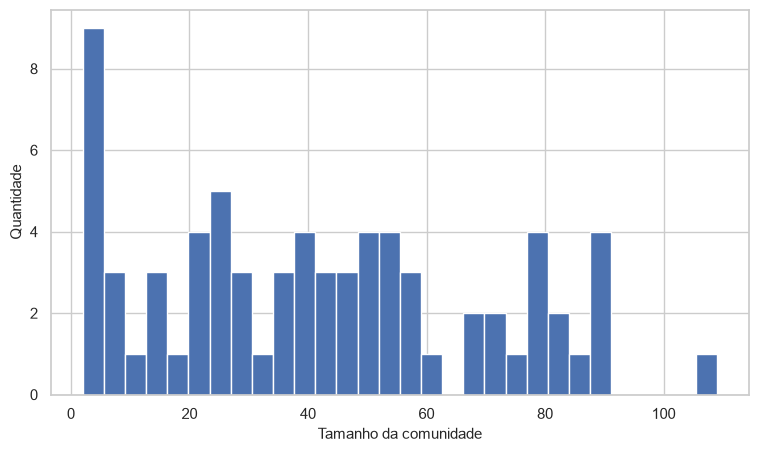

In [25]:
plt.hist(sizes, bins=30)
plt.xlabel("Tamanho da comunidade")
plt.ylabel("Quantidade")
plt.show()


In [26]:
print(len(largest_cc))
print(G.number_of_nodes())

print(
    len(largest_cc) / G.number_of_nodes()
)


3021
3112
0.9707583547557841


A detecção de comunidades foi realizada sobre a componente gigante da rede utilizando Louvain com pesos agregados por par não-direcionado de usuários. Antes do cálculo, chamadas recíprocas entre os mesmos dois usuários foram somadas, evitando que `nx.Graph` sobrescrevesse o peso de uma direção pela outra.

Com essa correção, foram identificadas 426 comunidades na componente gigante. A maior comunidade possui 369 usuários e a modularidade ponderada é aproximadamente 0,983, indicando uma estrutura bastante modular.

A distribuição dos tamanhos mostra muitas comunidades pequenas e médias, sem uma comunidade dominante que concentre grande parte dos usuários. Isso é compatível com redes de comunicação reais, nas quais os grupos tendem a refletir círculos sociais locais, como família, amizade, trabalho e vizinhança.

Para visualização espacial, é importante não colorir centenas de comunidades ao mesmo tempo com uma paleta pequena como `tab20`, pois as cores se repetem e comunidades diferentes passam a parecer iguais. Por isso, os mapas abaixo usam um recorte explícito das maiores comunidades, enquanto as estatísticas de tamanho e distribuição usam a tabela completa `community_df`.


---

> **Continuacao:** toda a analise espacial (coordenadas das antenas, mapa de Campinas, diagrama de
> Voronoi, distribuicao espacial das comunidades, decaimento com a distancia, homofilia
> socioeconomica e rede agregada entre antenas) esta no notebook **`3-analise-espacial.ipynb`**.